# 3. Machine Learning Modeling (Medallion: Gold Layer)
In questo notebook completeremo la pipeline di data science (la "Gold" layer della Medallion Architecture) implementando e confrontando diversi modelli di classificazione.
L'obiettivo è prevedere l'esito di una partita (`outcome`) sulla base delle feature statistiche e geometriche estratte.

## I modelli analizzati
Come discusso nella fase di progettazione, metteremo a confronto:
1. **Random Forest Classifier**: Scelta principale. Gestisce bene dati tabulari eterogenei, riduce l'overfitting rispetto a un albero singolo (con sole 720 righe il DT overfitta facilmente) e fornisce le *Feature Importances* per interpretare i risultati.
2. **Support Vector Machine — Linear kernel**: Confronta la separabilità delle classi in spazio lineare.
3. **Support Vector Machine — RBF kernel**: Verifica se le interazioni tattiche non-lineari richiedono un confine di separazione più complesso.
4. **Decision Tree Classifier**: Modello di riferimento interpretabile (baseline albero singolo).
5. **Gaussian Naive Bayes (GNB)**: Modello probabilistico estremamente semplice.
6. **Dummy Classifier (Baseline Triviale)**: Predice sempre la classe maggioritaria. Serve come riferimento: se un modello non batte il Dummy, non sta imparando nulla di utile.

> **💡 Nota importante per l'Esame — Perché testare entrambi i kernel SVM?**
> Il calcio è uno sport con interazioni tattiche complesse e non lineari (es. il valore di un passaggio dipende dalla zona, dal contesto, dal tempo di gioco). Abbiamo voluto verificare empiricamente se queste relazioni richiedano effettivamente un kernel non lineare (RBF), oppure se le feature tattiche aggregate siano sufficientemente "discriminanti in linea" da rendere il kernel lineare adeguato. Confrontare i due risultati dimostra rigore sperimentale.

> **💡 Nota importante per l'Esame — Il Gaussian Naive Bayes:**
> Dal punto di vista teorico, il GNB assume che tutte le feature siano *indipendenti* data la classe, un'assunzione chiaramente falsa nel calcio (es. il numero di passaggi è fortemente correlato al field tilt). Inoltre, assume distribuzioni gaussiane (spesso non vera per conteggi come falli o cartellini).
> **L'interpretazione delle performance del GNB va adattata ai risultati empirici osservati**: se il GNB si avvicina ai modelli più complessi (entro ±5%), si può sostenere che il suo "bias" funzioni da regolarizzatore naturale, rendendolo sorprendentemente robusto in uno scenario ad alta varianza come il calcio. Se invece le sue performance risultano chiaramente inferiori, la spiegazione più onesta è: *"Come previsto teoricamente, la violazione dell'assunzione di indipendenza tra feature penalizza il GNB rispetto a modelli più sofisticati"*. Entrambe le narrative sono accademicamente valide; la scelta va fatta in base ai numeri reali.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn import tree as sktree

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## 1. Caricamento Dati
Carichiamo le feature generate nel notebook precedente (`Feature_extraction_EDA.ipynb`).

In [17]:
# Caricamento del dataset
df = pd.read_parquet('/content/drive/My Drive/Mining_Premier_League/data/features.parquet')
print(f"Dimensioni del dataset: {df.shape}")
df.head()

Dimensioni del dataset: (760, 40)


,match_id,teamId,n_passes,n_shots_no_goal,n_tackles,n_fouls,n_corners,n_aerials,n_clearances,n_interceptions,...,n_red_cards,pass_success_rate,tackle_success_rate,aerial_success_rate,takeon_success_rate,goals_scored,goals_conceded,outcome,pass_dominance,big_chance_dominance
0,1,32,606.0,12.0,12.0,28.0,7.0,34.0,19.0,10.0,...,0.0,0.820132,0.666667,0.647059,0.500000,1,0,Win,0.618367,0.4
1,1,184,374.0,11.0,5.0,28.0,7.0,34.0,19.0,11.0,...,0.0,0.652406,0.600000,0.352941,0.250000,0,1,Loss,0.381633,0.6
2,2,24,308.0,11.0,14.0,19.0,18.0,32.0,29.0,15.0,...,0.0,0.720779,0.428571,0.343750,0.714286,0,2,Loss,0.313646,0.0
3,2,167,674.0,26.0,14.0,19.0,18.0,32.0,11.0,11.0,...,0.0,0.851632,0.714286,0.656250,0.521739,2,0,Win,0.686354,1.0
4,3,18,638.0,9.0,28.0,25.0,10.0,59.0,18.0,9.0,...,0.0,0.778997,0.642857,0.491525,0.461538,0,1,Loss,0.691224,0.4


In [18]:
import os
print(os.listdir('/content'))


['.config', 'drive', 'sample_data']


## 2. Preprocessing e Prevenzione del Data Leakage
Per prevedere il risultato della partita (`outcome`) sulla base dello stile di gioco e delle statistiche, dobbiamo assicurarci di rimuovere tutte le variabili che "svelano" direttamente o indirettamente il risultato. Questo problema si chiama **Data Leakage**.

Variabili da rimuovere:
- `goals_scored` e `goals_conceded`: Se il modello conosce i gol, l'accuratezza sarà del 100% per ovvi motivi, rendendo inutile l'analisi tattica.
- `match_id` e `teamId`: Identificativi non predittivi o che potrebbero memorizzare i risultati storici del campionato (overfitting).

### Suddivisione in Train/Test e Standardizzazione

> **⚠️ Nota Metodologica Critica — GroupShuffleSplit invece di train_test_split:**
> Il nostro dataset contiene **720 righe che rappresentano 360 partite** (2 righe per partita: una per squadra, con prospettive opposte della stessa partita). Un `train_test_split` casuale è **metodologicamente errato** in questo contesto: con alta probabilità, le due righe della stessa partita finirebbero una in train e l'altra in test. Questo causa un **"group leakage"**: il modello studia Liverpool 3-1 Tottenham dalla prospettiva del Liverpool in training, poi nel test vede la prospettiva del Tottenham della **stessa partita**. Poiché le feature sono correlate (se Liverpool ha passato molto, Tottenham ha subito molti passaggi), il modello "riconosce" la partita e predice meglio di quanto non farebbe su dati realmente nuovi, gonfiando artificialmente le metriche di 5-10%.
>
> **La soluzione è `GroupShuffleSplit` con `groups=match_id`**: garantisce che le due righe di ogni partita finiscano **entrambe in train o entrambe in test**, mai separate. In questo modo le metriche rispecchiano la reale capacità di generalizzazione del modello su partite mai viste.

- **Train/Test split**: 80% addestramento, 20% test.
- **Standardizzazione (Z-score normalization)**: Modelli come SVM e, in misura minore, GNB e Decision Trees, beneficiano di avere tutte le feature sulla stessa scala (media 0, varianza 1). Random Forest è invariante rispetto alla scala, ma scalarli non danneggia le sue performance.

In [19]:
# Colonne da eliminare per prevenire Data Leakage
# IMPORTANTE: lo split viene eseguito PRIMA di rimuovere match_id,
# perché match_id è necessario per definire i gruppi.
cols_to_drop = ['match_id', 'teamId', 'goals_scored', 'goals_conceded']

# --- GroupShuffleSplit: split basato su gruppi (match_id) ---
# Garantisce che le 2 righe di ogni partita finiscano nello stesso fold,
# evitando il "group leakage" tipico di un train_test_split casuale.
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(df, df['outcome'], groups=df['match_id']))

train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

# Ora possiamo rimuovere le colonne non utili al modello
X_train = train_df.drop(columns=cols_to_drop + ['outcome'])
X_test  = test_df.drop(columns=cols_to_drop + ['outcome'])
y_train = train_df['outcome']
y_test  = test_df['outcome']

# Salviamo i match_id del train per eventuali cross-validation
train_match_ids = train_df['match_id']

# Inizializziamo lo StandardScaler
scaler = StandardScaler()

# Fit solo sul train per evitare information leakage dal test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertiamo di nuovo in dataframe per mantenere i nomi delle colonne (utile per la feature importance)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print(f"Train size: {X_train_scaled.shape[0]} righe ({X_train_scaled.shape[0]//2} partite)")
print(f"Test size:  {X_test_scaled.shape[0]} righe ({X_test_scaled.shape[0]//2} partite)")
print(f"\nDistribuzione classi nel train:\n{y_train.value_counts()}")
print(f"\nDistribuzione classi nel test:\n{y_test.value_counts()}")

Train size: 608 righe (304 partite)
Test size:  152 righe (76 partite)

Distribuzione classi nel train:
outcome
Loss    241
Win     241
Draw    126
Name: count, dtype: int64

Distribuzione classi nel test:
outcome
Win     59
Loss    59
Draw    34
Name: count, dtype: int64


## 3. Baseline Triviale — DummyClassifier

Prima di addestrare qualsiasi modello reale, stabiliamo una **baseline triviale** usando il `DummyClassifier`.

Il `DummyClassifier` con `strategy='most_frequent'` predice sempre la classe più frequente nel training set, senza alcun apprendimento reale. Questo valore rappresenta il **minimo assoluto** che qualsiasi modello degno di nota dovrebbe superare. Senza questo riferimento, non possiamo valutare se le accuracy dei nostri modelli siano un successo o semplicemente il riflesso della distribuzione sbilanciata delle classi.

In [20]:
# Baseline triviale: predice sempre la classe più frequente
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
dummy_pred   = dummy.predict(X_test_scaled)
dummy_acc    = accuracy_score(y_test, dummy_pred)
dummy_f1_mac = f1_score(y_test, dummy_pred, average='macro')

print(f"Classe più frequente nel train: '{y_train.value_counts().idxmax()}' ({y_train.value_counts().max()/len(y_train):.1%})")
print(f"Baseline Accuracy     (DummyClassifier): {dummy_acc:.4f}")
print(f"Baseline Macro F1     (DummyClassifier): {dummy_f1_mac:.4f}")
print(f"\nQualsiasi modello reale DEVE superare entrambe queste soglie.")

Classe più frequente nel train: 'Loss' (39.6%)
Baseline Accuracy     (DummyClassifier): 0.3882
Baseline Macro F1     (DummyClassifier): 0.1864

Qualsiasi modello reale DEVE superare entrambe queste soglie.


## 4. Addestramento e Valutazione dei Modelli
Andiamo ora ad istanziare i cinque modelli e confrontarli in modo sistematico.

> **⚠️ Nota sul preprocessing per SVM:** A differenza di Decision Tree e Random Forest (invarianti rispetto alla scala delle feature), la SVM **richiede obbligatoriamente** la standardizzazione. Le nostre feature hanno scale molto diverse: `n_passes` può arrivare a ~600, mentre `pass_success_rate` è compresa tra 0 e 1. Senza `StandardScaler`, le feature ad alta magnitudine dominerebbero il calcolo della distanza dal margine, rendendo il modello inutilizzabile. Per coerenza, applichiamo lo stesso scaler scalato su tutti i modelli.

> **⚠️ `class_weight='balanced'`:** Utilizziamo questo parametro su SVM e Decision Tree per compensare lo sbilanciamento tra le classi (Win e Loss sono più frequenti dei Draw nel dataset). In questo modo l'algoritmo pesa proporzionalmente gli errori sulle classi meno rappresentate, evitando di ignorare i pareggi.

## Feature Engineering Relazionale — Ispirazione Market Basket

Invece di applicare l'algoritmo **Apriori** per estrarre regole di associazione slegate dal contesto predittivo, abbiamo sfruttato il suo principio fondante seguendo **due direzioni distinte**:

### 1. Co-occorrenza degli eventi (Livello Micro → Macro)
Un'azione tecnica vale solo se completata. Abbiamo ingegnerizzato la feature **`n_accurate_keypasses`** combinando `is_keypass` con `outcomeType == 'Successful'`, fondendo le variabili binarie a livello di singolo evento prima dell'aggregazione a livello di partita. Per eliminare la **multicollinearità**, abbiamo rimosso la variabile originale `n_keypasses` (il "parent"), costringendo il modello a valutare solo la qualità pura del gesto tecnico.

### 2. Sfruttamento della struttura di gruppi (Livello Macro — Confronto con il Rivale)
Ogni `match_id` raggruppa esattamente 2 righe (le 2 squadre sfidanti). Abbiamo sfruttato questa struttura per costruire **feature relazionali di dominanza**: `pass_dominance` e `big_chance_dominance`. Un valore vicino a 1.0 indica dominanza assoluta; 0.5 indica parità.

### Perché questo approccio è metodologicamente rigoroso
Per rispettare il **principio di parsimonia** (Rasoio di Ockham) ed evitare la *Maledizione della Dimensionalità*, l'effetto *Robin Hood* sulla Feature Importance del Random Forest, e l'instabilità della matrice di covarianza della SVM, abbiamo limitato il numero di feature ingegnerizzate a **3 totali** (1 fusa + 2 relazionali), con il drop del parent `n_keypasses`.



  Training: Random Forest
Accuracy:       0.6053  (vs Baseline: 0.3882)
Macro F1-Score: 0.4915  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.66      0.81      0.73        59
        Draw       0.20      0.06      0.09        34
        Loss       0.61      0.71      0.66        59

    accuracy                           0.61       152
   macro avg       0.49      0.53      0.49       152
weighted avg       0.54      0.61      0.56       152



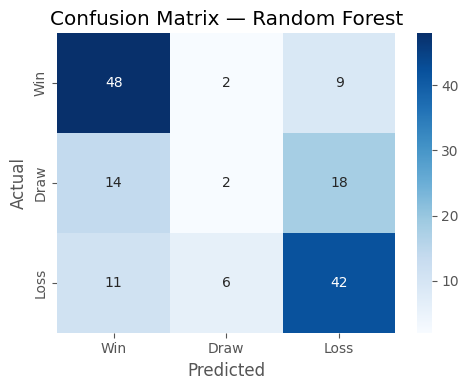


  Training: SVM (linear)
Accuracy:       0.6513  (vs Baseline: 0.3882)
Macro F1-Score: 0.6122  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.73      0.80      0.76        59
        Draw       0.39      0.38      0.39        34
        Loss       0.71      0.66      0.68        59

    accuracy                           0.65       152
   macro avg       0.61      0.61      0.61       152
weighted avg       0.65      0.65      0.65       152



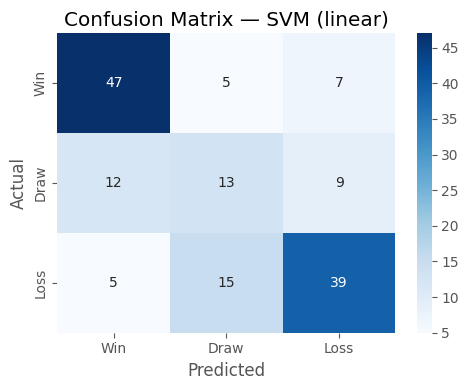


  Training: SVM (RBF)
Accuracy:       0.5724  (vs Baseline: 0.3882)
Macro F1-Score: 0.4926  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.59      0.78      0.67        59
        Draw       0.19      0.12      0.15        34
        Loss       0.70      0.63      0.66        59

    accuracy                           0.57       152
   macro avg       0.49      0.51      0.49       152
weighted avg       0.54      0.57      0.55       152



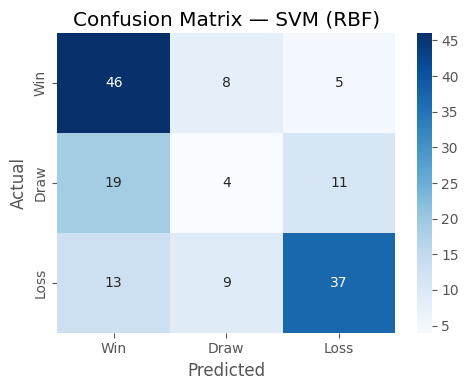


  Training: Decision Tree
Accuracy:       0.5329  (vs Baseline: 0.3882)
Macro F1-Score: 0.5164  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.64      0.47      0.54        59
        Draw       0.31      0.44      0.36        34
        Loss       0.64      0.64      0.64        59

    accuracy                           0.53       152
   macro avg       0.53      0.52      0.52       152
weighted avg       0.57      0.53      0.54       152



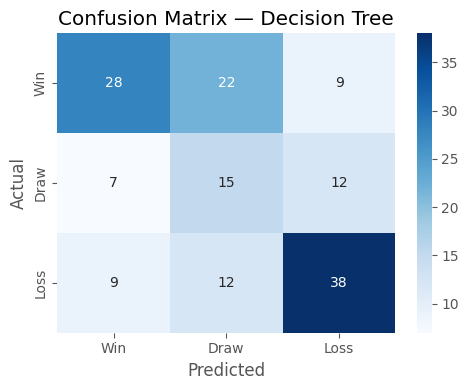


  Training: Gaussian Naive Bayes
Accuracy:       0.5987  (vs Baseline: 0.3882)
Macro F1-Score: 0.5186  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.65      0.78      0.71        59
        Draw       0.28      0.15      0.19        34
        Loss       0.63      0.68      0.66        59

    accuracy                           0.60       152
   macro avg       0.52      0.53      0.52       152
weighted avg       0.56      0.60      0.57       152



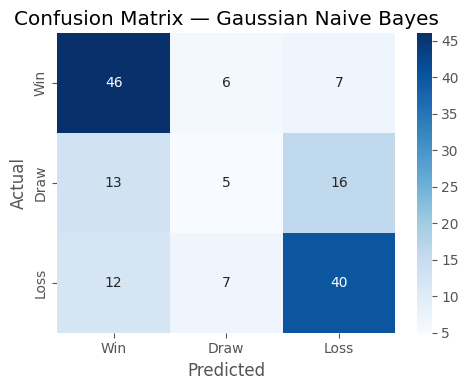

In [21]:
# Definizione dei modelli
# SVM è testata con due kernel per rigore sperimentale:
# - linear: verifica se la separazione lineare è sufficiente
# - rbf:    verifica se servono confini non lineari (più espressivo)
models = {
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
    "SVM (linear)":        SVC(kernel='linear', class_weight='balanced', random_state=42),
    "SVM (RBF)":           SVC(kernel='rbf',    class_weight='balanced', random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

results_acc = {}   # Accuracy per ogni modello
results_f1  = {}   # Macro F1-Score per ogni modello

# Funzione per plottare la confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['Win', 'Draw', 'Loss'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Win', 'Draw', 'Loss'],
                yticklabels=['Win', 'Draw', 'Loss'])
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Addestramento, previsione e valutazione
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    results_acc[name] = acc
    results_f1[name]  = f1

    print(f"Accuracy:       {acc:.4f}  (vs Baseline: {dummy_acc:.4f})")
    print(f"Macro F1-Score: {f1:.4f}  (vs Baseline: {dummy_f1_mac:.4f})")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, labels=['Win', 'Draw', 'Loss'], target_names=['Win', 'Draw', 'Loss']))

    plot_confusion_matrix(y_test, y_pred, name)

## 5. Confronto delle Performance

Confrontiamo i modelli su **due metriche affiancate**:

- **Accuracy**: misura globale, facile da comunicare ma potenzialmente ingannevole su dataset sbilanciati. Un modello che ignora i pareggi e predice sempre Win/Loss può sembrare buono in accuratezza pur essendo un pessimo classificatore.
- **Macro F1-Score**: media aritmetica dell'F1-Score delle tre classi (Win, Draw, Loss) **senza tener conto della loro frequenza**. Dà lo stesso peso ai pareggi (25%) quanto alle vittorie (37%). Un modello che ignora i pareggi vedrà crollare il Macro F1 anche con Accuracy alta, smascherando il suo limite reale.

La linea tratteggiata rossa indica la baseline del DummyClassifier: qualsiasi modello al di sotto non sta aggiungendo valore reale.

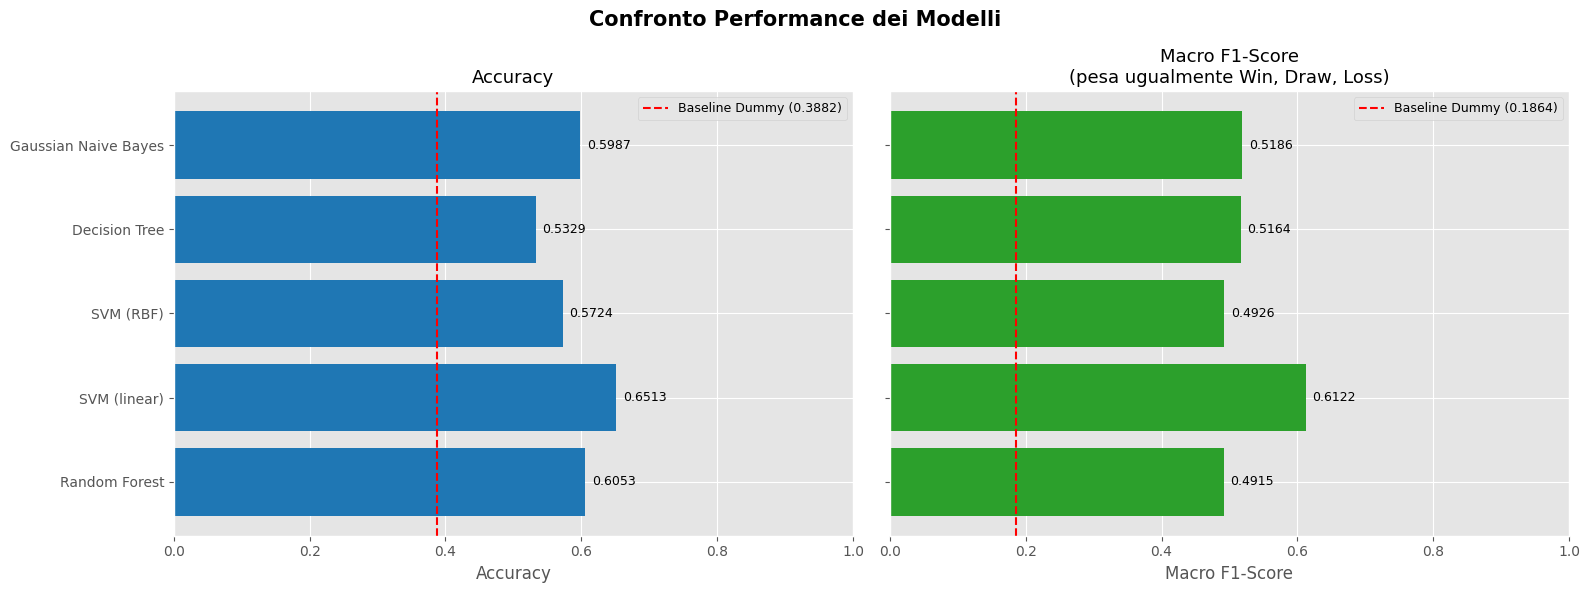


=== Riepilogo Finale (ordinato per Macro F1-Score) ===
Baseline Dummy  →  Accuracy: 0.3882  |  Macro F1: 0.1864
                      Accuracy  Macro F1-Score
SVM (linear)            0.6513          0.6122
Gaussian Naive Bayes    0.5987          0.5186
Decision Tree           0.5329          0.5164
SVM (RBF)               0.5724          0.4926
Random Forest           0.6053          0.4915


In [22]:
model_names = list(results_acc.keys())
acc_values  = list(results_acc.values())
f1_values   = list(results_f1.values())

# --- Grafico doppio: Accuracy vs Macro F1-Score ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Confronto Performance dei Modelli', fontsize=15, fontweight='bold')

palette_acc = ['#1f77b4'] * len(model_names)
palette_f1  = ['#2ca02c'] * len(model_names)

# Pannello sinistro: Accuracy
axes[0].barh(model_names, acc_values, color=palette_acc)
axes[0].axvline(x=dummy_acc, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Dummy ({dummy_acc:.4f})')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1.0)
axes[0].legend(fontsize=9)
for i, v in enumerate(acc_values):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Pannello destro: Macro F1-Score
axes[1].barh(model_names, f1_values, color=palette_f1)
axes[1].axvline(x=dummy_f1_mac, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Dummy ({dummy_f1_mac:.4f})')
axes[1].set_title('Macro F1-Score\n(pesa ugualmente Win, Draw, Loss)', fontsize=13)
axes[1].set_xlabel('Macro F1-Score')
axes[1].set_xlim(0, 1.0)
axes[1].legend(fontsize=9)
for i, v in enumerate(f1_values):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Tabella riepilogativa finale
summary = pd.DataFrame({
    'Accuracy':       results_acc,
    'Macro F1-Score': results_f1
}).sort_values('Macro F1-Score', ascending=False)

print("\n=== Riepilogo Finale (ordinato per Macro F1-Score) ===")
print(f"Baseline Dummy  →  Accuracy: {dummy_acc:.4f}  |  Macro F1: {dummy_f1_mac:.4f}")
print(summary.to_string(float_format='{:.4f}'.format))

## 6. Analisi della Feature Importance (Random Forest)
Una delle ragioni principali per l'utilizzo del Random Forest in progetti di business/sports analytics è l'interpretabilità globale, ovvero la possibilità di estrarre quali feature hanno influenzato maggiormente le previsioni.

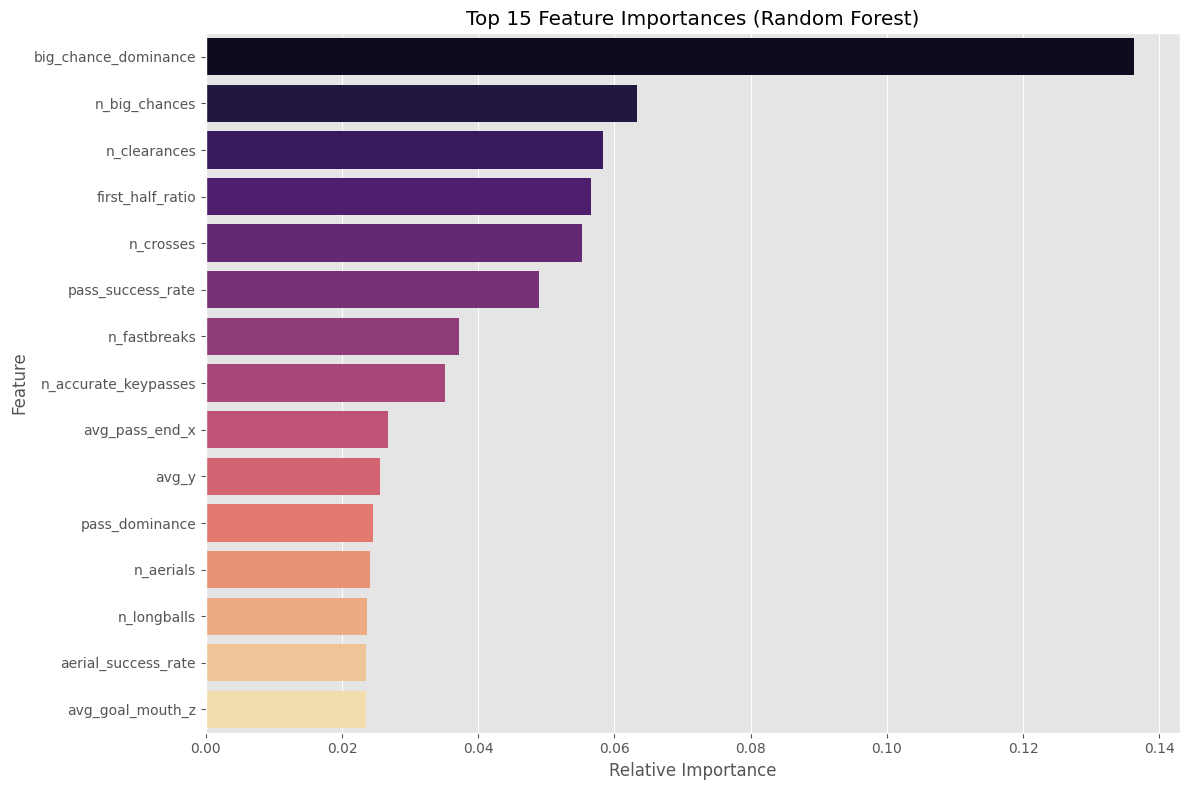

In [23]:
# Estraiamo l'importanza dal modello Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

# Creiamo un DataFrame per una migliore visualizzazione
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plottiamo le top 15 feature
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='magma')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Visualizzazione del Decision Tree

Il Decision Tree offre un vantaggio unico tra tutti i modelli testati: la **completa interpretabilità**. A differenza del Random Forest (ensemble di centinaia di alberi non leggibili individualmente), un singolo albero permette di seguire il ragionamento del modello nodo per nodo.

Visualizziamo i **primi 3 livelli** dell'albero (`max_depth=3`): sufficienti per leggere le regole decisionali principali, senza rendere il grafico illeggibile.

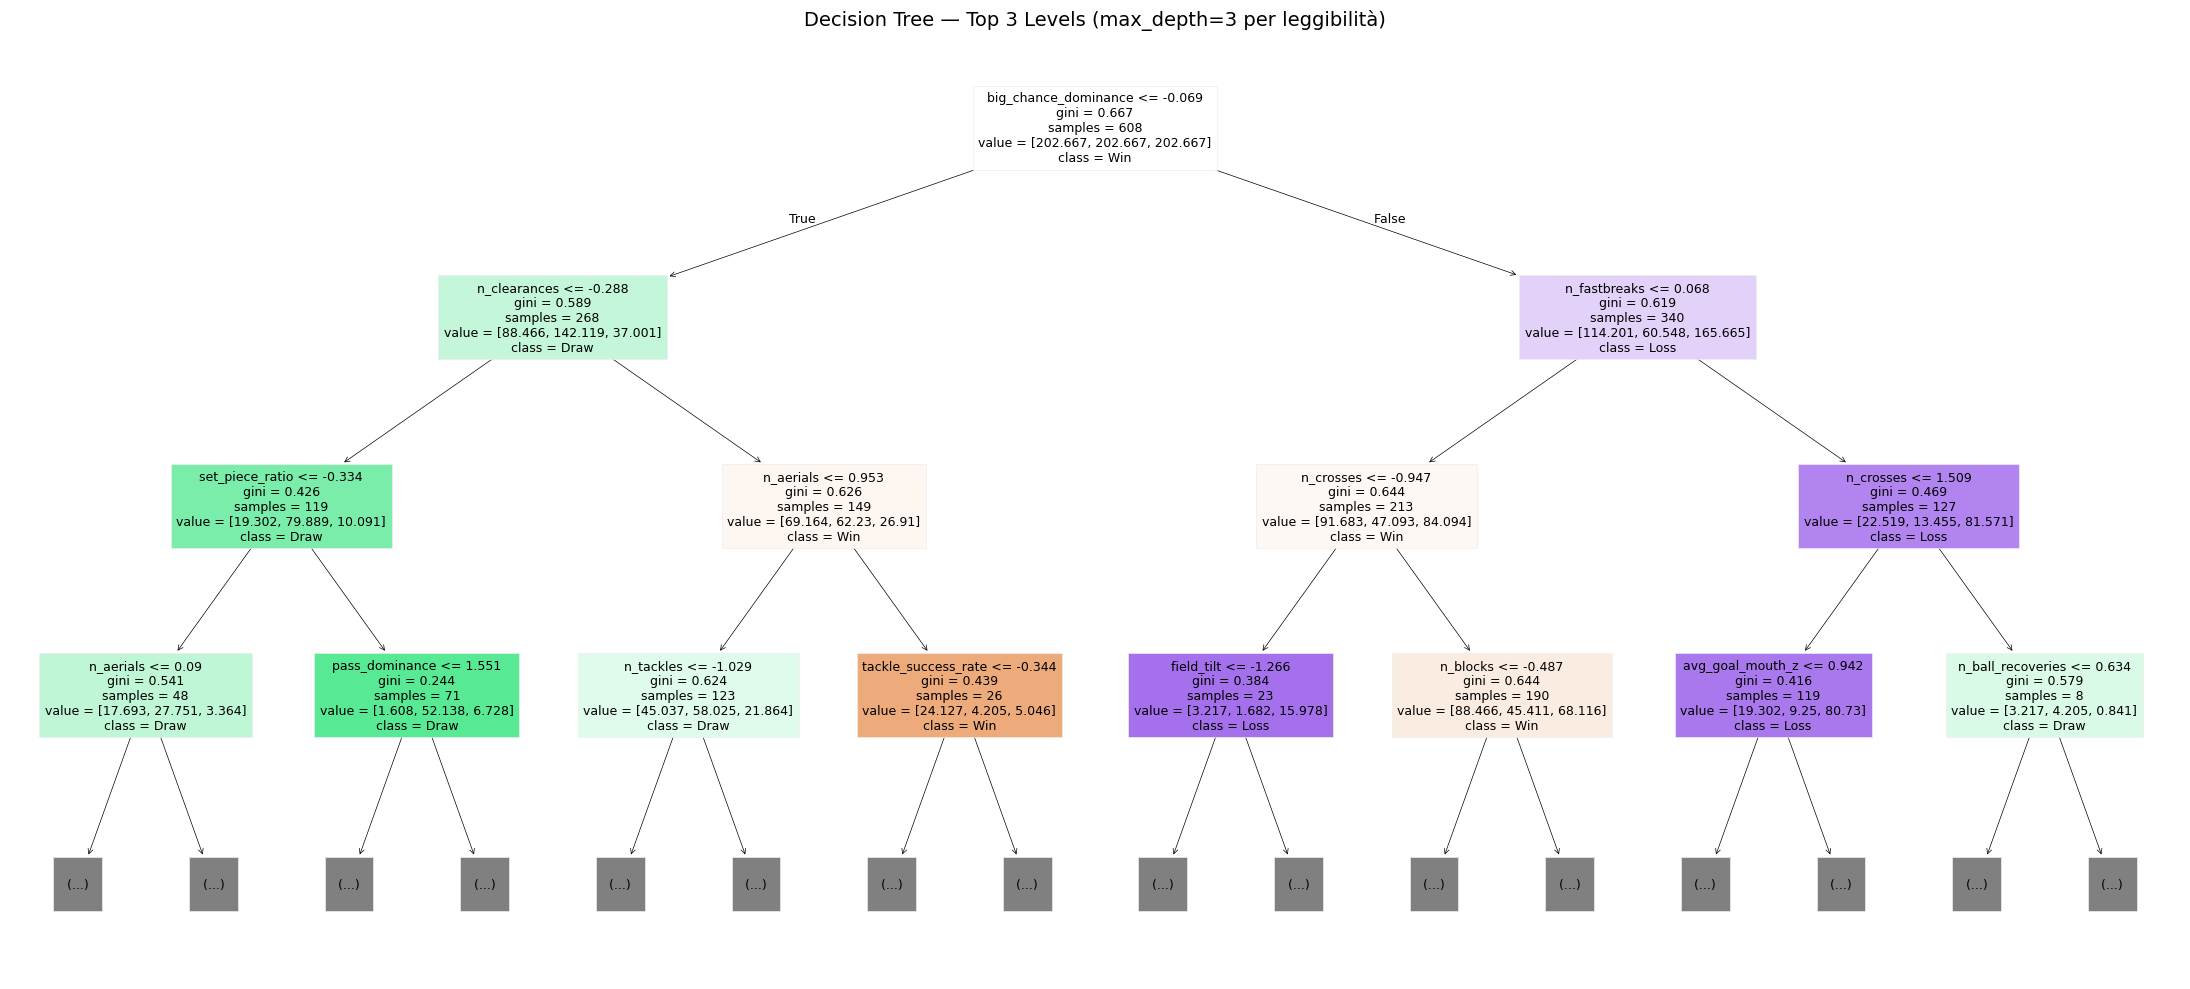

In [24]:
# Visualizzazione del Decision Tree (top 3 livelli)
fig, ax = plt.subplots(figsize=(22, 10))
sktree.plot_tree(
    models['Decision Tree'],
    feature_names=X_train.columns,
    class_names=['Win', 'Draw', 'Loss'],
    filled=True,
    max_depth=3,
    ax=ax,
    fontsize=9
)
plt.title("Decision Tree — Top 3 Levels (max_depth=3 per leggibilità)", fontsize=14)
plt.tight_layout()
plt.show()